In [1]:
### import signature from 
%matplotlib inline

import matplotlib.pyplot as plt 
import numpy as np
plt.rcParams['figure.dpi'] = 120
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True

In [2]:
### read in the data files

output_path = '/mnt/ceph/users/vpandya/sapphire_outputs/outputs/'

npz_cpu = np.load(output_path+'benchmark_cpu.npz',allow_pickle=True)
npz_gpu1 = np.load(output_path+'benchmark_1gpu64cpu.npz',allow_pickle=True)
npz_gpu4 = np.load(output_path+'benchmark_4gpu64cpu.npz',allow_pickle=True)
npz_gpu8 = np.load(output_path+'benchmark_8gpu64cpu.npz',allow_pickle=True)

npz_cpu.files,npz_gpu1.files,npz_gpu4.files, npz_gpu8.files

(['tsolves_jit',
  'tsolves_avg',
  'tjacs_jit',
  'tjacs_avg',
  'Ncombos_shmap',
  'tsolves_batch_jit',
  'tsolves_batch',
  'tjacs_batch_jit',
  'tjacs_batch'],
 ['tsolves_jit',
  'tsolves_avg',
  'tjacs_jit',
  'tjacs_avg',
  'Ncombos_shmap',
  'tsolves_batch_jit',
  'tsolves_batch',
  'tjacs_batch_jit',
  'tjacs_batch'],
 ['tsolves_jit',
  'tsolves_avg',
  'tjacs_jit',
  'tjacs_avg',
  'Ncombos_shmap',
  'tsolves_batch_jit',
  'tsolves_batch',
  'tjacs_batch_jit',
  'tjacs_batch'],
 ['tsolves_jit',
  'tsolves_avg',
  'tjacs_jit',
  'tjacs_avg',
  'Ncombos_shmap',
  'tsolves_batch_jit',
  'tsolves_batch',
  'tjacs_batch_jit',
  'tjacs_batch'])

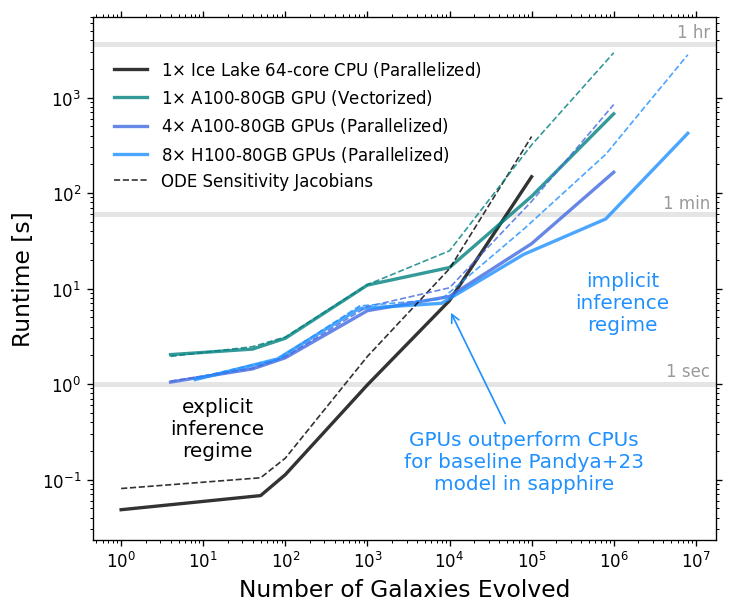

In [67]:
c_cpu, c_gpu1, c_gpu4, c_gpu8 = 'k','teal','royalblue','dodgerblue'

fig, ax = plt.subplots(1,figsize=(6,5),constrained_layout=True)

### first plot CPU
ax.loglog(np.hstack([1,npz_cpu['Ncombos_shmap']]),
          np.hstack([npz_cpu['tsolves_avg'],npz_cpu['tsolves_batch']]),'-',#marker='s',mfc='none',ms=5,
          label=r'1$\times$ Ice Lake 64-core CPU (Parallelized)',lw=2,alpha=0.8,color=c_cpu)


# now single-GPU
ax.loglog(npz_gpu1['Ncombos_shmap'],npz_gpu1['tsolves_batch'],'-',#marker='s',mfc='none',ms=5,
          label=r'1$\times$ A100-80GB GPU (Vectorized)',lw=2,alpha=0.8,color=c_gpu1)

# now 4 multi-GPU
ax.loglog(npz_gpu4['Ncombos_shmap'],npz_gpu4['tsolves_batch'],'-',#marker='s',mfc='none',ms=5,
          label=r'4$\times$ A100-80GB GPUs (Parallelized)',lw=2,alpha=0.8,color=c_gpu4)

# now 8 multi-GPU
ax.loglog(npz_gpu8['Ncombos_shmap'],npz_gpu8['tsolves_batch'],'-',#marker='s',mfc='none',ms=5,
          label=r'8$\times$ H100-80GB GPUs (Parallelized)',lw=2,alpha=0.8,color=c_gpu8)


# now gradients 
ax.loglog(np.hstack([1,npz_cpu['Ncombos_shmap']]),
          np.hstack([npz_cpu['tjacs_avg'],npz_cpu['tjacs_batch']]),'--',#marker='s',mfc='none',ms=5,
          label=r'ODE Sensitivity Jacobians',lw=1,alpha=0.8,color=c_cpu)

ax.loglog(npz_gpu1['Ncombos_shmap'],npz_gpu1['tjacs_batch'],'--',#marker='s',mfc='none',ms=5,
          label='__none__',lw=1,alpha=0.8,color=c_gpu1)
ax.loglog(npz_gpu4['Ncombos_shmap'],npz_gpu4['tjacs_batch'],'--',#marker='s',mfc='none',ms=5,
          label='__none__',lw=1,alpha=0.8,color=c_gpu4)
ax.loglog(npz_gpu8['Ncombos_shmap'],npz_gpu8['tjacs_batch'],'--',#marker='s',mfc='none',ms=5,
          label='__none__',lw=1,alpha=0.8,color=c_gpu8)

### also the jits as thin transparent lines (all same except lw and alpha)
# ax.loglog(npz_cpu['Nsequential'][0],npz_cpu['tjit'],'kv',label='__none__',mfc='none',alpha=0.6)
# # ax.loglog(npz_cpu['Nsequential'][0],npz_cpu['tjit_vmap'][0],'kv',label='__none__',mfc='none',alpha=0.6)
# ax.loglog(npz_cpu['Nbatches'][:-1],npz_singlecpu['tjit_vmap'],'k:',label='__none__',lw=0.5,alpha=0.6)
# ax.loglog(npz_singlecpu['Nbatches_shmap'][:-1],npz_singlecpu['tjit_shmap'],'k--',label='__none__',lw=0.5,alpha=0.6)

# ax.loglog(npz_singlegpu['Nsequential'][0],npz_singlegpu['tjit'],'rv',mfc='none',alpha=0.6,label='__none__')
# ax.loglog(npz_singlegpu['Nbatches'],npz_singlegpu['tjit_vmap'],'r:',label='__none__',lw=0.5,alpha=0.6)
# ax.loglog(npz_multigpu['Nbatches'],npz_multigpu['tjit_shmap'],'r--',label='__none__',lw=0.5,alpha=0.6)

# ax.text(0.4,0.95,'CPU = Single 64-core Intel Icelake',transform=ax.transAxes,fontsize=9,color='k')
# ax.text(0.4,0.9,'GPUs = Nvidia A100-80GB',transform=ax.transAxes,fontsize=9,color='r')

leg = ax.legend(loc='lower left',ncols=1,fontsize=10,bbox_to_anchor=(0.01, 0.64, 0.5, 0.5),fancybox=True,framealpha=0)
# ax.add_artist(leg)
# custom_lines = [Line2D([0], [0], color='k', linestyle='-'),
#                 Line2D([0], [0], color='k', lw=0.5,alpha=0.6 ,linestyle='-')]
# legb = ax.legend(custom_lines, ['runtime', 'jit-compile'],loc='lower right',fontsize=10,bbox_to_anchor=(0.98,0.05))

ax.axhline(1.0,color='k',zorder=0,alpha=0.1,lw=3)
ax.axhline(60.0,color='k',zorder=0,alpha=0.1,lw=3)
ax.axhline(3600.0,color='k',zorder=0,alpha=0.1,lw=3)
ax.axhline(3600.0*24,color='k',zorder=0,alpha=0.1,lw=3)
ax.text(1.5e7,1.2,'1 sec',fontsize=10,color='gray',alpha=0.8,ha='right')
ax.text(1.5e7,70,'1 min',fontsize=10,color='gray',alpha=0.8,ha='right')
ax.text(1.5e7,4.3e3,'1 hr',fontsize=10,color='gray',alpha=0.8,ha='right')
# ax.text(1.7e6,1.3e5,'1 day',fontsize=8,color='gray',alpha=0.6,ha='right')

# ax.set_xlabel('Number of ODE Solves (Batch Size)',fontsize=14)
# ax.set_xlabel('Number of Galaxy ODE Solves',fontsize=14)
ax.set_xlabel('Number of Galaxies Evolved',fontsize=14)
ax.set_ylabel('Runtime [s]',fontsize=14)

ax.annotate('GPUs outperform CPUs\nfor baseline Pandya+23\nmodel in sapphire',
            xy=(10000, 6),  # (x, y) coordinate to point to
            xytext=(80000, 8e-2),  # where to place the text
            arrowprops=dict(arrowstyle='->', color=c_gpu8),
            fontsize=12, color=c_gpu8,ha='center')

ax.set_ylim(None,7e3)

ax.text(0.2,0.16,'explicit\ninference\nregime',fontsize=12,color='k',ha='center',transform=ax.transAxes)
ax.text(0.85,0.4,'implicit\ninference\nregime',fontsize=12,color=c_gpu8,ha='center',transform=ax.transAxes)


plt.savefig('/mnt/ceph/users/vpandya/sapphire_outputs/figures/figure_runtime_combined_final.png',
            facecolor='w',bbox_inches='tight',dpi=300)